### Q1 Reading - The ProShares ETF Product

**1.1 Alternative ETFs: Describe the two types of investments referenced by this term.**

'Alternative ETFs' is a loose concept that generally includes two types of investments: 

(1) alternative asset classes (giving exposure to nonmainstream assets). These provide exposure to real, hard or financial assets such as real estate, commodities, previous metals, currencies, volatility, or private equity. 

(2) alternative strategies (pursuing investment processes that were not constrained and oculd use leverage, shorting and derivatives). These provide exposure to geared investing (leveraged and inverse investing), long/short strategies, market neutral, absolute return, convertible/merger arbitrage, managed futures, and global macro. 



**1.2a. Using just the information in the case, what are two measures by which hedge funds are an attractive investment?**

1. The Hedge Fund Research Index (HFRI) exhibited attractive risk-return characteristics in terms of the Sharpe ratio. From the period of 1994 to 2013, the HFRI composite exhibited less than half the volatility of the S&P 500 and earned annualized returns less than 1% below those of the index.

2. The HFRI also exhibited attractive properties of downside protection. The case showed that hedge funds experienced about half the drawdown of equities during the 2008 crisis. 

**b. What are the main benefits of investing in hedge funds via an ETF instead of directly?**

The main benefit is that hedge fund replication ETFs democratize access to diversified hedge fund exposures (in effect provide hedge fund beta). These allow investors to access quantitative, rules-based investment strategies that also seek to capture the risk/return characteristics of hedge funds as an asset class. 

Hedge fund replication ETTFs also charge lower fees than traditional hedge funds (which often used the 2% management fee, 20% performance fee model) and allow access to retail investors. 



**1.3a. Explain as simply as possible how HFRI, MLFM, MLFM-ES, and HDG differ in their construction and purpose.**

The Hedge Fund Research Index (HFRI) is constructed using the HFR database as a comprehensive resource for hedge fund investors. The purpose of the index is to display the collective performance of hedge funds through an equally weighted composite of over 2,000 constituent hedge funds that are available to accredited investors. 

​Merrill Lynch Factor Model (MLFM) is constructed via six factors: S&P 500, Russell 2000, MSCI EAFE, MSCI Emerging Markets, the Eurodollar/U.S. dollar exchange rate, and the three-month Eurodollar Deposit yields. The purpose is to replicate hedge fund risk and return characteristics without actually investing in hedge funds. 

Merrill Lynch Factor Model–Exchange Series (MLFM-ES) is constructed such that the six components of the MLFM are tradable. It also substitutes three-month Eurodollar deposit yields with U.S. Treasury Bills and dollar/euro exchange rates with ProShares UltraShort Euro (EUO). The purpose is to track the Merrill Lynch Factor Model with near-perfect correlation. 

HDG is constructed by using long or short physical positions in stocks or bonds, and synthetic positions via swaps and futures to create the factor exposures. Its purpose is to provide investors with hedge fund exposure by tracking the MLFM-ES. 

**b. How well does the Merrill Lynch Factor Model (MLFM) track the HFRI?**

The Merrill Lynch Factor Model achieves a correlation coefficient of 90% with the HFRI. 

**c. In which factor does the MLFM have the largest loading? (See a slide in Exhibit 1.)**

The factor with the largest loading for the MLFM is 3-Month T-Bills. The T-Bills exhibit a factor weight of 66.50%. 

**d. What are the main concerns you have for how the MLFM attempts to replicate the HFRI?**

​The main concern is that the model uses the prior 24 months of returns to estimate the ‘optimal’ factor weights. Financial market factors that generate alpha can move quickly; factors that drove outperformance in hedge fund strategies over the past 24 months may no longer be optimal for hedge funds a month from now. Therefore, the replication will, by construction (using regressions), lag behind the real returns of the HFRI. Instead, an alternative approach could be to apply exponential weighting to the data or make more informed probabilistic assumptions about the factors that hedge funds will focus on in the near future.


**1.4a What does ProShares ETF, HDG, attempt to track? Is the tracking error small?**

HDG attempts to track the Merrill Lynch Factor Model by targeting a high correlation to it. The benchmark that was created for tracking purposes was the Merrill Lynch Factor Model – Exchange Series. 

The tracking error between the ProShares ETF, HDG, and the MLFM-ES is relatively small. The Fact Sheet–ProShares Hedge Replication ETF (HDG) shows that, Since Inception, the ProShares ETF returned 1.77%, while the MLFM-ES it attempts to replicate returned 2.69%. 

Therefore, tracking error has been approximately 0.92% per annum since inception, which could be considered relatively minor slippage.

**b. HDG is, by construction, delivering beta for investors. Isn’t the point of hedge funds to generate alpha? Then why would HDG be valuable?**

HDG is valuable because it can provide retail investors with better risk-adjusted returns than a traditional 60/40 portfolio and offer diversification across the six factors the instrument tracks. 

Hedge funds have also historically shown attractive downside protection, as seen when they experienced about half the drawdown of equities during the 2008 crisis. 

HDG also gives retail investors access to professional, sophisticated strategies without the fees or capital lockups typically required.

**c. The fees of a typical hedge-fund are 2% on total assets plus 20% of excess returns if positive. HDG’s expense ratio is roughly 1% on total assets. What would their respective net Sharpe Ratios be, assuming both have a gross excess returns of 10% and volatility of 20%?**

The Sharpe Ratio is constructed via (E[r] - r_f)/σ. 

Sharpe_{typical hedge fund} = (80% of 10% - 2% mgmt fee)/20% = 6%/20% = 0.30. 

Sharpe_HDG = (10% - 1%)/(20%) = 0.45. 


# 2. Analyzing the Data

Monthly data from `proshares_analysis_data.xlsx` (Aug 2011 – May 2025).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from IPython.display import display
import statsmodels.api as sm


#Hedge fund series and Merrill factors (for the risk-free rate) of the data
hf = pd.read_excel('FINM Portfolio/proshares_analysis_data.xlsx', sheet_name = 'hedge_fund_series', index_col = 0, parse_dates=True)
factors = pd.read_excel('FINM Portfolio/proshares_analysis_data.xlsx', sheet_name = 'merrill_factors', index_col = 0, parse_dates=True)

#Risk-free rate: 3-month T-bill (USGG3M), already in monthly return units
rf = factors['USGG3M Index'] # Use USGG3M as the risk-free rate
hf_excess = hf.sub(rf, axis = 0) # Obtain the hedge fund excess returns, NOT the absolute returns

hf.head()

,HFRIFWI Index,MLEIFCTR Index,MLEIFCTX Index,HDG US Equity,QAI US Equity
2011-08-31,-0.032149,-0.025588,-0.025689,-0.027033,-0.006492
2011-09-30,-0.038903,-0.032414,-0.032593,-0.032466,-0.022142
2011-10-31,0.026858,0.043593,0.043320,0.050531,0.025244
2011-11-30,-0.013453,-0.012142,-0.012431,-0.028608,-0.007965
2011-12-31,-0.004479,0.001938,0.001796,0.012874,0.001818


## 2.1. Summary Statistics (annualized)

Monthly data, so we annualize the mean by 12 and the volatility by $\sqrt{12}$.
The Sharpe ratio uses excess returns (over the 3-month T-bill, `USGG3M`):

$$\text{Sharpe} = \frac{\sqrt{12}\,\mu^{e}}{\sigma^{e}}$$

In [ ]:
#Annualization factor for monthly data
ann = 12
summary = pd.DataFrame({
    'Mean': hf.mean() * ann,
    'Vol': hf.std() * np.sqrt(ann),
    'Excess Mean': hf_excess.mean() * ann,
    'Excess Vol': hf_excess.std() * np.sqrt(ann),
})
summary['Sharpe (expressed in excess returns)'] = summary['Excess Mean'] / summary['Excess Vol']

summary.style.format({'Mean': '{:.2%}', 'Vol': '{:.2%}', 'Excess Mean': '{:.2%}', 'Excess Vol': '{:.2%}', 'Sharpe (expressed in excess returns)': '{:.2f}'})

,Mean,Vol,Excess Mean,Excess Vol,Sharpe (expressed in excess returns)
HFRIFWI Index,5.13%,5.88%,3.63%,5.88%,0.62
MLEIFCTR Index,3.85%,5.52%,2.34%,5.51%,0.43
MLEIFCTX Index,3.65%,5.51%,2.14%,5.50%,0.39
HDG US Equity,2.69%,5.74%,1.18%,5.73%,0.21
QAI US Equity,2.88%,4.98%,1.37%,4.94%,0.28


## 2.2 Tail-Risk Statistics (not annualized)

- Skewness and excess kurtosis (pandas `.kurt()` already reports kurtosis in excess of 3)
- VaR (.05): 5th quantile of historic monthly returns
- CVaR (.05): mean of returns at or below the 5th quantile
- Maximum drawdown, computed from the cumulative wealth index $W_t = \prod_{s \le t}(1 + r_s)$:
  drawdown $= W_t / \max_{s \le t} W_s - 1$

In [ ]:
def max_drawdown(r):
    """
    wealth = dropna removes missing months, (1+r) turns from percentage into ratios e.g. +10% means 1.10, .cumprod() multiplies the ratios one after the other
    peaks = identify the highest value seen up to this month
    drawdown = current return compared to the highest return seen so far, converted from ratio to percentage. Done for each month.
    troughdate = the biggest drawdown's date
    peakdate = the date of the highest return, before that trough date
    recovery_date = date after the trough date, and when the returns reach the previous old peak
    """
    wealth = (1 + r.dropna()).cumprod()
    peaks = wealth.cummax()
    drawdown = wealth / peaks - 1
    trough_date = drawdown.idxmin()
    peak_date = wealth[:trough_date].idxmax()
    peak_value = wealth[peak_date]
    recovered = wealth[trough_date:][wealth[trough_date:] >= peak_value]
    recovery_date = recovered.index[0] if len(recovered) > 0 else pd.NaT

    return pd.Series({
        'Max Drawdown': drawdown.min(),
        'Peak': peak_date,
        'Bottom': trough_date,
        'Recovery': recovery_date,
        'Duration (to recovery)': recovery_date - peak_date if pd.notna(recovery_date) else 'Not recovered',
    })

VaR = hf.quantile(0.05)

tail_risk = pd.DataFrame({
    'Skewness': hf.skew(),
    'Excess Kurtosis': hf.kurt(),
    'VaR (0.05)': VaR,
    'CVaR (0.05)': hf[hf <= VaR].mean(),
})

drawdowns = hf.apply(max_drawdown).T
tail_risk = tail_risk.join(drawdowns)

tail_risk.style.format({'Skewness': '{:.2f}', 'Excess Kurtosis': '{:.2f}', 'VaR (0.05)': '{:.2%}', 'CVaR (0.05)': '{:.2%}', 'Max Drawdown': '{:.2%}',
                        'Peak': '{:%Y-%m-%d}', 'Bottom': '{:%Y-%m-%d}', 'Recovery': lambda d: d.strftime('%Y-%m-%d') if pd.notna(d) else 'Not recovered'})

,Skewness,Excess Kurtosis,VaR (0.05),CVaR (0.05),Max Drawdown,Peak,Bottom,Recovery,Duration (to recovery)
HFRIFWI Index,-0.95,5.66,-2.40%,-3.60%,-11.55%,2019-12-31,2020-03-31,2020-08-31,244 days 00:00:00
MLEIFCTR Index,-0.29,1.63,-2.70%,-3.50%,-12.43%,2021-06-30,2022-09-30,2024-02-29,974 days 00:00:00
MLEIFCTX Index,-0.27,1.59,-2.70%,-3.49%,-12.44%,2021-06-30,2022-09-30,2024-02-29,974 days 00:00:00
HDG US Equity,-0.27,1.78,-2.99%,-3.68%,-14.07%,2021-06-30,2022-09-30,2024-07-31,1127 days 00:00:00
QAI US Equity,-0.43,1.45,-1.72%,-3.10%,-13.77%,2021-06-30,2022-09-30,2024-02-29,974 days 00:00:00


## 2.3 Regression on SPY

For each hedge fund series, regress its excess return on SPY's excess return (with an intercept):

$$r^e_{i,t} = \alpha_i + \beta_i \, r^e_{SPY,t} + \epsilon_{i,t}$$

- **Market Beta** $\beta$: how much the fund moves when SPY moves 1%. Not annualized (it's a ratio of monthly returns, so the units cancel).
- **Treynor Ratio** $= \dfrac{12 \times \text{mean}(r^e)}{\beta}$: excess return per unit of market risk. Annualized like the mean.
- **Information Ratio** $= \dfrac{12 \times \alpha}{\sqrt{12} \times \sigma_\epsilon} = \sqrt{12}\,\dfrac{\alpha}{\sigma_\epsilon}$: return not explained by SPY, per unit of risk not explained by SPY. Annualized like the Sharpe ratio.

In [ ]:
spy_excess = factors['SPY US Equity'] - rf


def regress_on_market(y, x, ann = 12):
    '''
    Regression with intercept: y = alpha + beta * x + error
    missing = 'drop' skips months where either series is missing (HFRIFWI is missing the last month)
    Dependent Variable Y is the fund's excess returns
    Independent Variable X is SPY excess returns
    '''

    X = sm.add_constant(x.rename('SPY')) # add a column of 1s to account for the alpha or the intercept
    results = sm.OLS(y, X, missing = 'drop').fit() # fit OLS model
    alpha, beta = results.params['const'], results.params['SPY']

    return pd.Series({
        'Alpha (annualized)': alpha * ann,
        'Market Beta': beta, # already annualized because the scale of 12 gets cancelled at both numerator and denominator, so monthly and yearly betas are the same
        'Treynor Ratio': results.model.endog.mean() * ann / beta, # endog is Y (dependent variable),
        'Information Ratio': alpha * ann / (results.resid.std() * np.sqrt(ann)),
        'R-squared': results.rsquared,
    })

regression = hf_excess.apply(lambda y: regress_on_market(y, spy_excess)).T

regression.style.format({'Alpha (annualized)': '{:.2%}', 'Market Beta': '{:.2f}', 'Treynor Ratio': '{:.2%}', 'Information Ratio': '{:.2f}', 'R-squared': '{:.2f}'})

,Alpha (annualized),Market Beta,Treynor Ratio,Information Ratio,R-squared
HFRIFWI Index,-0.80%,0.35,10.50%,-0.26,0.72
MLEIFCTR Index,-2.09%,0.34,6.86%,-0.83,0.79
MLEIFCTX Index,-2.28%,0.34,6.29%,-0.90,0.79
HDG US Equity,-3.36%,0.35,3.37%,-1.22,0.77
QAI US Equity,-2.52%,0.30,4.57%,-1.04,0.76


## 2.4

#### SPY vs Hedge Fund

- SPY earned much more in terms of mean, and had better risk adjusted returns (sharpe), as compared to hedge funds
- Hedge funds are less risky because they have about a third of SPY's volatility, about a half of worst month losses using VaR, cVaR and max drawdown
- Hedge funds can be seen as a ratio of around 30:70 SPY and T-bills, because of the following reasons:
    - beta of around 0.3, which illustrates that hedge funds are about a third of general market volatility
    - Negative alpha implies no extra returns
- Hedge funds have higher kurtosis (fat tails), which suggest that in market downturns, hedge funds are more extreme relative to their normal behaviours. 


#### QAI vs HDG

- QAI performed better than HDG based on almost every financial metric, with the exception of skewness. 


#### HDG and ML series capturing properties of HFRI
- near identical betas, around 0.34–0.35 for HFRI, ML series and HDG.
- similar volatilities at 5.5-5.9%
- However, HDG trails both HFRI and ML series in terms of mean returns and in turn, sharpe ratios. 
- HFRI is distinct in terms of its strong negative skew and fat tails, which cannot be replicated by both the ML series and HDG. Both ML series and HDG have milder negative skews and fat tails


## 2.5 Correlation Matrix

,HFRIFWI Index,MLEIFCTR Index,MLEIFCTX Index,HDG US Equity,QAI US Equity
HFRIFWI Index,1.000,0.901,0.900,0.890,0.858
MLEIFCTR Index,0.901,1.000,1.000,0.988,0.894
MLEIFCTX Index,0.900,1.000,1.000,0.988,0.893
HDG US Equity,0.890,0.988,0.988,1.000,0.879
QAI US Equity,0.858,0.894,0.893,0.879,1.000


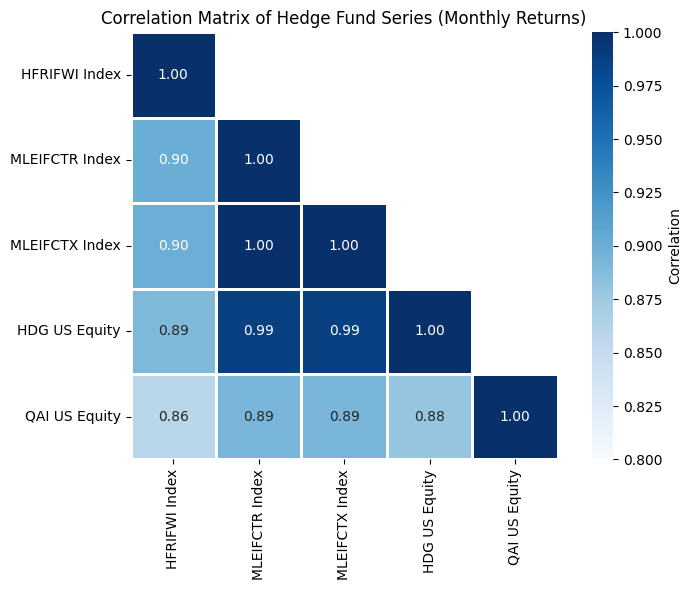

Highest: ('MLEIFCTX Index', 'MLEIFCTR Index') 0.9999
Lowest: ('QAI US Equity', 'HFRIFWI Index') 0.8578


In [ ]:
#Correlation matrix of monthly returns
corr = hf.corr()
display(corr.round(3))

#Heat map (upper triangle hidden since it mirrors the lower triangle)
mask = np.triu(np.ones_like(corr, dtype = bool), k = 1)
plt.figure(figsize = (8, 6))
sns.heatmap(corr, mask = mask, annot = True, fmt = '.2f', cmap = 'Blues', vmin = 0.8, vmax = 1,
            square = True, linewidths = 2, linecolor = 'white', cbar_kws = {'label': 'Correlation'})
plt.title('Correlation Matrix of Hedge Fund Series (Monthly Returns)')
plt.tight_layout()
plt.show()

#Highest and lowest correlations (each pair counted once, excluding the diagonal)
pairs = corr.where(np.tril(np.ones_like(corr, dtype = bool), k = -1)).stack().sort_values()
print('Highest:', pairs.idxmax(), round(pairs.max(), 4))
print('Lowest:', pairs.idxmin(), round(pairs.min(), 4))

## 2.6. Replicating HFRI with the Merrill Factors

Unrestricted regression of HFRI on all six Merrill factors, with a constant:

$$r^{hfri}_t = \alpha^{merr} + x^{merr}_t \beta^{merr} + \epsilon^{merr}_t$$

Returns are used as given (not excess), since the T-bill (`USGG3M`) is itself one of the six factors.

In [ ]:
#Dependent variable Y is HFRI, independent variables X are the six Merrill factors
y_hfri = hf['HFRIFWI Index']
X_merr = sm.add_constant(factors) # add a column of 1s to account for the alpha or the intercept

results_merr = sm.OLS(y_hfri, X_merr, missing = 'drop').fit()

#a. Intercept and betas
params = results_merr.params.rename({'const': 'Intercept (alpha)'})
display(params.to_frame('Coefficient').style.format('{:.4f}'))
print(f"Annualized alpha: {results_merr.params['const'] * 12:.2%}")

#b. Position sizes: how much of each factor the replication holds
betas = results_merr.params.drop('const')
print(f"Sum of betas (net position):          {betas.sum():.2f}")
print(f"Sum of |betas| (gross position size): {betas.abs().sum():.2f}")

#c. R-squared
print(f"R-squared: {results_merr.rsquared:.4f}")

#d. Tracking error = volatility of the residuals, annualized
tracking_error = results_merr.resid.std() * np.sqrt(12)
print(f"Tracking error (annualized): {tracking_error:.2%}")

,Coefficient
Intercept (alpha),0.0011
SPY US Equity,0.0435
USGG3M Index,0.3249
EEM US Equity,0.0856
EFA US Equity,0.0740
EUO US Equity,0.0296
IWM US Equity,0.1458


Annualized alpha: 1.38%
Sum of betas (net position):          0.70
Sum of |betas| (gross position size): 0.70
R-squared: 0.8427
Tracking error (annualized): 2.33%


- Every beta is positive, so there is not shorting involved. 